# Neuro-AI: Mapping Deep Learning Architectures to the Human Visual Cortex
**Author:** Tanvi Gambhir

### Project Overview
This project bridges the gap between Artificial Intelligence and Cognitive Neuroscience. The goal is to determine which layers of an Artificial Neural Network (ANN) best align with specific functional Regions of Interest (ROIs) in the human brain.

By extracting visual features from mid-to-late ANN layers, we train Ridge Regression encoding models to predict human neural responses. We evaluate these models across three distinct brain regions:
* **FFA (Fusiform Face Area):** Specialized for facial recognition.
* **PPA (Parahippocampal Place Area):** Specialized for scene/landscape processing.
* **EBA (Extrastriate Body Area):** Specialized for body part recognition.

In [ ]:
!pip install git+https://github.com/murtylab/neuroai-notebooks.git

  Cloning https://github.com/murtylab/neuroai-notebooks.git to /tmp/pip-req-build-pcll2kfo
  Running command git clone --filter=blob:none --quiet https://github.com/murtylab/neuroai-notebooks.git /tmp/pip-req-build-pcll2kfo
  Resolved https://github.com/murtylab/neuroai-notebooks.git to commit c193d58d76ed3c4facd12173bcd7dc2c5f46e486
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git --no-deps
!pip install git+https://github.com/murtylab/neuroai-notebooks.git --upgrade
!mkdir datasets

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_r3ybx13
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_r3ybx13
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/murtylab/neuroai-notebooks.git to /tmp/pip-req-build-mg25zy24
  Running command git clone --filter=blob:none --quiet https://github.com/murtylab/neuroai-notebooks.git /tmp/pip-req-build-mg25zy24
  Resolved https://github.com/murtylab/neuroai-notebooks.git to commit c193d58d76ed3c4facd12173bcd7dc2c5f46e486
  Preparing metadata (setup.py) ... done
mkdir: cannot create directory ‘datasets’: File exists


In [ ]:
import torch
from neuroai.models import CLIPRN50

backbone_model = CLIPRN50(pretrained=True, download_root="./pretrained_checkpoints")

In [ ]:
from neuroai.datasets import NSDAllSubjectSingleRegion
from neuroai.utils import ForwardHook
import torch.nn as nn
import torch
from neuroai.utils.regression import RidgeModel, ridge_regression

## here's a bunch of functions from the other notebook to make your life easier
def collect_features_and_voxels(
    dataset: NSDAllSubjectSingleRegion,
    backbone_model: nn.Module,
    hook: ForwardHook,
    device: str,
    subject_id: str
):

    ## this is where we dump our data
    all_features = []
    all_fmri_voxels = []

    with torch.no_grad():
        for i in range(len(dataset)):
            image: torch.Tensor = dataset[i]["image"]

            ## (voxels) -> (1, voxels)
            fmri_data: torch.Tensor = dataset[i]["fmri_response"][subject_id].unsqueeze(0)

            ## (channels, height, width) -> (1, channels, height, width)
            image = image.unsqueeze(0)
            image = image.to(device)
            y = backbone_model(image)

            ## making sure that we're moving stuff back to the RAM with .cpu()
            hook_output = hook.output.cpu()
            all_features.append(hook_output)
            all_fmri_voxels.append(fmri_data.cpu())

    return {
        "features": torch.cat(all_features, dim=0),
        "voxels": torch.cat(all_fmri_voxels, dim=0)
    }

In [ ]:
from neuroai.models import CLIPRN50

backbone_model = CLIPRN50(pretrained=True, download_root="./pretrained_checkpoints")
backbone_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
backbone_model = backbone_model.to(device)

## first, look at the model and select a few layers
print(backbone_model)

CLIPRN50(
  (model): ModifiedResNet(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu3): ReLU(inplace=True)
    (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
  

In [ ]:
region = "FFA"

layers_to_evaluate = [
    ## select a few layers to evaluate over
    "model.layer4.0.conv1",
    "model.layer2.1.conv2",
    "model.layer3.2.conv1",
    "model.layer1.2.conv2",
    "model.layer4.2.conv1"
]

### 1. Feature Extraction & Ridge Regression Modeling
To compare the artificial model to the biological brain, we treat the ANN as a "computational hypothesis" for human vision.
1. We pass visual stimuli through the ANN and extract the activated features from 5 distinct layers.
2. For each brain region (FFA, PPA, EBA), we train a **Ridge Regression** model mapping the ANN layer's features to the actual fMRI data of a human subject.
3. The models are evaluated on a held-out test subject using Pearson correlation to ensure out-of-sample generalization.

In [ ]:
from neuroai.utils.regression import ridge_regression
from neuroai.utils.regression import RidgeModel

layers_to_evaluate = [
    "model.layer4.0.conv1",
    "model.layer2.1.conv2",
    "model.layer3.2.conv1",
    "model.layer1.2.conv2",
    "model.layer4.2.conv1"
]

results = {}
for layer_name in layers_to_evaluate:
    hook = ForwardHook(backbone_model, layer_name)
    collected_data = collect_features_and_voxels(
        dataset=dataset,
        backbone_model=backbone_model,
        hook=hook,
        device=device,
        subject_id="s1"
    )

    ridge_result = ridge_regression(
        x_train=collected_data["features"],
        y_train=collected_data["voxels"],
        flatten_x=True,
        predict_mean=False
    )

    model = RidgeModel(
        backbone_model=backbone_model,
        transforms=backbone_model.transforms,
        hook_layer_name=layer_name,
        ridge_result=ridge_result,
    )
    results[layer_name] = model


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.06376e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.73549e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.09269e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.35748e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.0521e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
from neuroai.datasets import download_and_extract_nsd

download_and_extract_nsd(zip_filename = "nsd.zip", output_folder = "./datasets")
from neuroai.datasets import NSDAllSubjectSingleRegion
import torch.nn as nn
dataset = NSDAllSubjectSingleRegion(
    folder="./datasets/nsd",
    region=region,
    transforms=backbone_model.transforms,
    subset="train",
    train_test_split=0.8
)

features_from_different_layers = {}

for layer_name in layers_to_evaluate:
    print(f"Processing layer {layer_name}")

    hook = ForwardHook(
        model=backbone_model,
        hook_layer_name=layer_name
    )

    collected_data = collect_features_and_voxels(
        dataset=dataset,
        backbone_model=backbone_model,
        hook=hook,
        device=device,
        subject_id="s1"
    )

    features = collected_data["features"]
    voxels = collected_data["voxels"]

    print(f"Features shape: {features.shape}, Voxels shape: {voxels.shape}")

    features_from_different_layers[layer_name] = features
    hook.close()  # clean up the hook

Extracted NSD dataset to ./datasets
Processing layer model.layer4.0.conv1
Features shape: torch.Size([800, 512, 14, 14]), Voxels shape: torch.Size([800, 156])
Processing layer model.layer2.1.conv2
Features shape: torch.Size([800, 128, 28, 28]), Voxels shape: torch.Size([800, 156])
Processing layer model.layer3.2.conv1
Features shape: torch.Size([800, 256, 14, 14]), Voxels shape: torch.Size([800, 156])
Processing layer model.layer1.2.conv2
Features shape: torch.Size([800, 64, 56, 56]), Voxels shape: torch.Size([800, 156])
Processing layer model.layer4.2.conv1
Features shape: torch.Size([800, 512, 7, 7]), Voxels shape: torch.Size([800, 156])


### 2. Neuro-AI Alignment: Visualizing the Correlation
If an ANN layer has a high correlation score with a specific brain region, it suggests that the artificial layer and the biological tissue are processing information in a mathematically similar way.

Below, we visualize the Pearson correlation scores across different layers for the FFA, PPA, and EBA to determine where the artificial network most closely mimics the human visual cortex.


--- Region: FFA ---
  Layer: model.layer4.0.conv1... 

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.06376e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Score: 0.6901
  Layer: model.layer2.1.conv2... 

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.73549e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Score: 0.5732
  Layer: model.layer3.2.conv1... 

...

Score: 0.7068
  Layer: model.layer1.2.conv2... 

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.35748e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Score: 0.4534
  Layer: model.layer4.2.conv1... 

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.0521e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Score: 0.7774


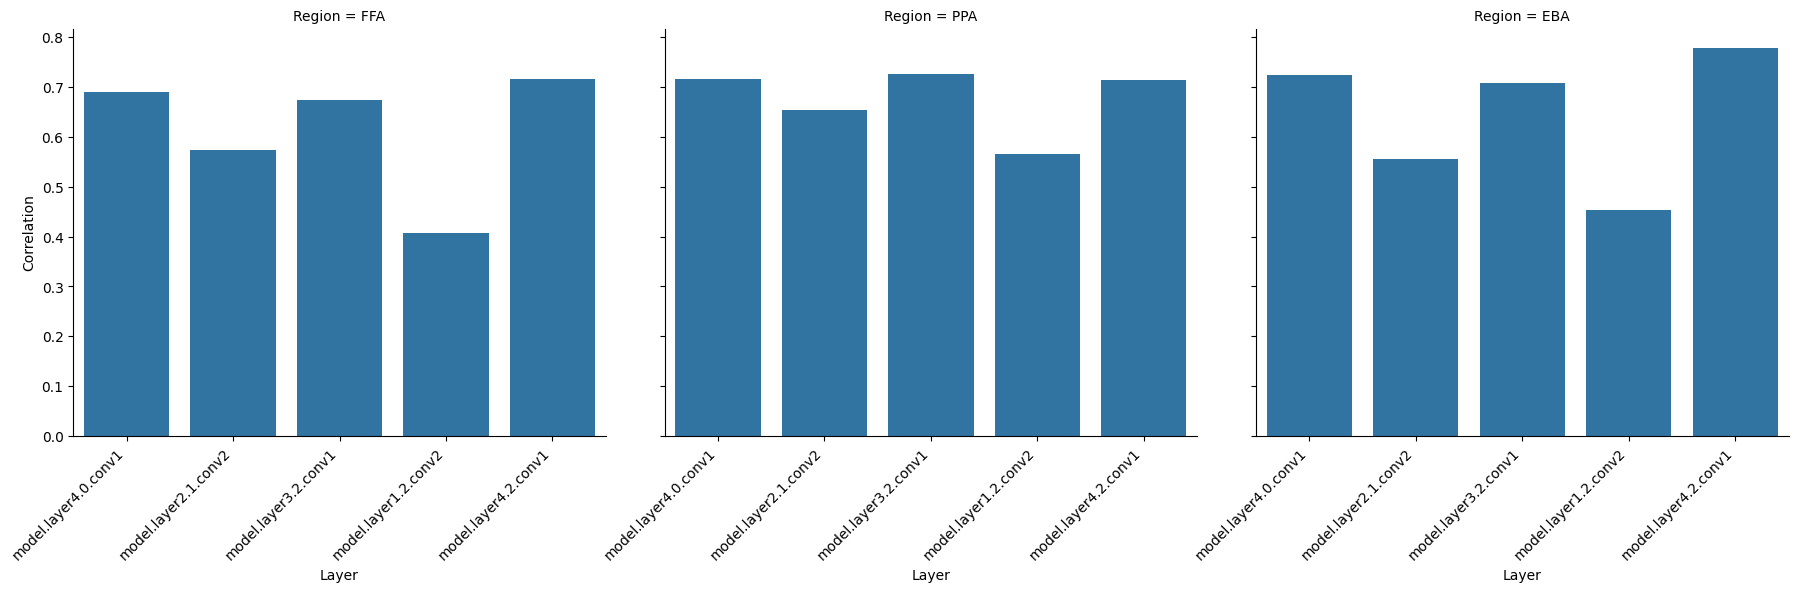

Best for FFA: model.layer4.2.conv1 (Score: 0.7162)
Best for PPA: model.layer3.2.conv1 (Score: 0.7251)
Best for EBA: model.layer4.2.conv1 (Score: 0.7774)


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import gc
from neuroai.models import CLIPRN50
from neuroai.datasets import NSDAllSubjectSingleRegion, download_and_extract_nsd
from neuroai.utils import ForwardHook
from neuroai.utils.regression import ridge_regression, RidgeModel

def collect_features_and_voxels(dataset, backbone_model, hook, device, subject_id):
    all_features = []
    all_fmri_voxels = []
    with torch.no_grad():
        for i in range(len(dataset)):
            image = dataset[i]["image"].unsqueeze(0).to(device)
            fmri_data = dataset[i]["fmri_response"][subject_id].unsqueeze(0)
            _ = backbone_model(image)
            all_features.append(hook.output.cpu())
            all_fmri_voxels.append(fmri_data.cpu())
    return {
        "features": torch.cat(all_features, dim=0),
        "voxels": torch.cat(all_fmri_voxels, dim=0)
    }
if 'backbone_model' not in locals():
    download_and_extract_nsd(zip_filename="nsd.zip", output_folder="./datasets")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    backbone_model = CLIPRN50(pretrained=True, download_root="./pretrained_checkpoints")
    backbone_model.eval()
    backbone_model.to(device)

regions_to_test = ["FFA", "PPA", "EBA"]
layers_to_test = [
    "model.layer4.0.conv1",
    "model.layer2.1.conv2",
    "model.layer3.2.conv1",
    "model.layer1.2.conv2",
    "model.layer4.2.conv1"
]

train_subj = "s1"
eval_subj = "s2"
results_data = []


for region in regions_to_test:
    print(f"\n--- Region: {region} ---")

    for layer_name in layers_to_test:
        print(f"  Layer: {layer_name}...", end=" ")

        hook = ForwardHook(backbone_model, layer_name)

        try:
            train_dataset = NSDAllSubjectSingleRegion(
                folder="./datasets/nsd", region=region,
                transforms=backbone_model.transforms,
                subset="train", train_test_split=0.8
            )

            train_data = collect_features_and_voxels(
                train_dataset, backbone_model, hook, device, train_subj
            )


            ridge_result = ridge_regression(
                x_train=train_data["features"],
                y_train=train_data["voxels"],
                flatten_x=True, predict_mean=False
            )

            model = RidgeModel(
                backbone_model=backbone_model,
                transforms=backbone_model.transforms,
                hook_layer_name=layer_name,
                ridge_result=ridge_result,
            )

            del train_dataset, train_data
            gc.collect()

            eval_dataset = NSDAllSubjectSingleRegion(
                folder="./datasets/nsd", region=region,
                transforms=backbone_model.transforms,
                subset="test", train_test_split=0.8
            )

            eval_data = collect_features_and_voxels(
                eval_dataset, backbone_model, hook, device, eval_subj
            )

            score = model.evaluate(
                x_test=eval_data["features"],
                y_test=eval_data["voxels"],
                predict_mean=True, flatten_x=True
            )

            print(f"Score: {score:.4f}")
            results_data.append({"Region": region, "Layer": layer_name, "Correlation": score})
            del eval_dataset, eval_data, model, ridge_result
            gc.collect()
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"Error: {e}")
        finally:
            hook.close()

if results_data:
    df = pd.DataFrame(results_data)
    g = sns.catplot(
        data=df, x="Layer", y="Correlation", col="Region",
        kind="bar", col_wrap=3, height=5, aspect=1.2
    )
    g.set_xticklabels(rotation=45, ha="right")
    plt.show()


    for region in regions_to_test:
        r_df = df[df["Region"] == region]
        if not r_df.empty:
            best = r_df.loc[r_df["Correlation"].idxmax()]
            print(f"Best for {region}: {best['Layer']} (Score: {best['Correlation']:.4f})")